In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("household_power_consumption.csv")
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [3]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

In [4]:
df = df.set_index('Datetime')

In [5]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

In [6]:
df = df.dropna()

In [7]:
df = df[['Global_active_power']]

In [8]:
df = df.resample('h').mean()

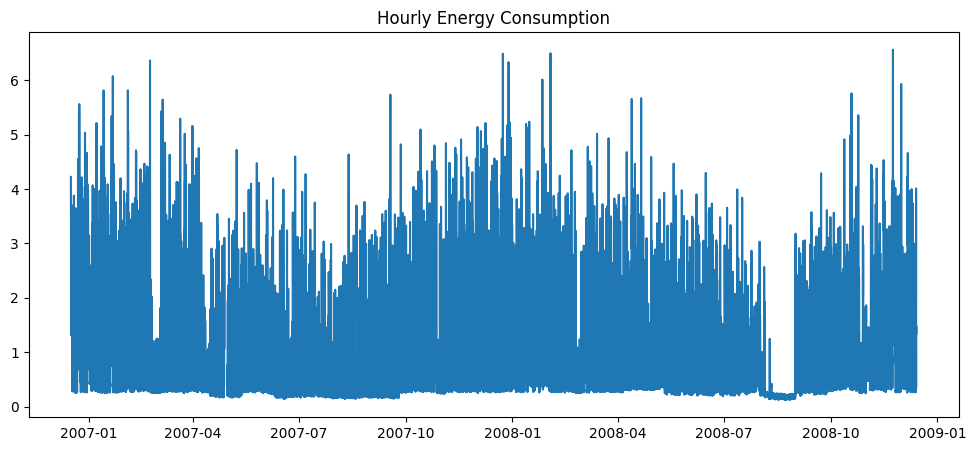

In [9]:
plt.figure(figsize=(12,5))
plt.plot(df)
plt.title("Hourly Energy Consumption")
plt.show()

In [15]:
from statsmodels.tsa.arima.model import ARIMA

train_size = int(len(df)*0.8)
train = df[:train_size]
test = df[train_size:]

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

In [16]:
print("MAE:", mean_absolute_error(test, pred))
print("RMSE:", np.sqrt(mean_squared_error(test, pred)))

MAE: 0.712744629783251
RMSE: 1.1195223565065469


In [17]:
from xgboost import XGBRegressor

df['lag1'] = df['Global_active_power'].shift(1)
df = df.dropna()

X = df[['lag1']]
y = df['Global_active_power']

train_size = int(len(df)*0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

model = XGBRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [18]:
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

MAE: 0.3990994514920396
RMSE: 0.5824148031660018


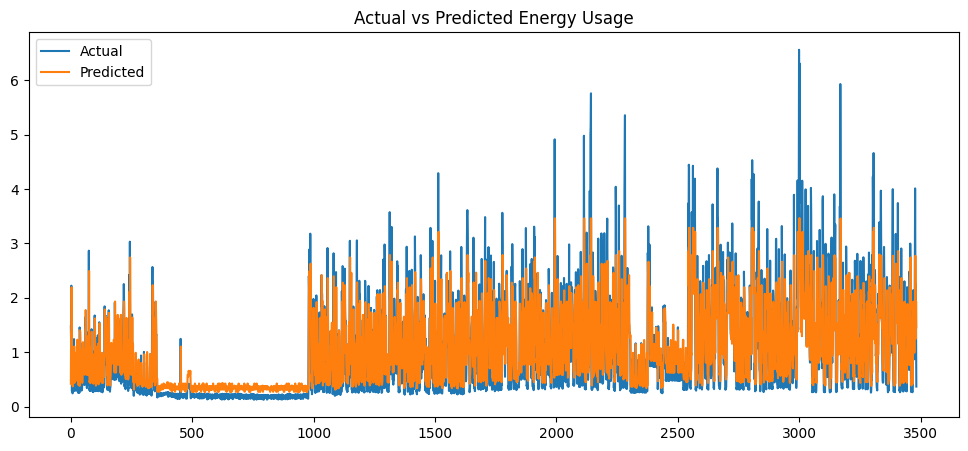

In [19]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Energy Usage")
plt.show()

## Insights

- Energy consumption shows strong hourly patterns
- ARIMA captures trend but struggles with noise
- XGBoost performs better with lag features
- Resampling improves stability of forecasting